#  Student CGPA Prediction — Random Forest Regressor

**Dataset:** `student_dropout_dataset_v3.csv`  
**Task:** Regression — Prediksi nilai **CGPA**  
**Model:** Random Forest Regressor

---
###  Daftar Isi
1. Cara Melihat Tipe Data
2. Dataset Bisa Digunakan Untuk Apa
3. Model Yang Bisa Digunakan
4. Parameter Yang Bisa Diubah/Disetel
5. Evaluasi Yang Dipakai
6. Cara Mengetahui Evaluasi Bagus atau Tidak
7. Cara Mengoptimasi Model
8. Cara Menyimpan Model
9. Cara Menggunakan Model Hasil Training

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('Libraries loaded ')

Libraries loaded 


---
## 1.  Cara Melihat Tipe Data

In [2]:
df = pd.read_csv('../student_dropout_dataset_v3.csv')
print('Shape:', df.shape)
df.info()

Shape: (10000, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  object 
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  object 
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  object 
 10  Scholarship            10000 non-null  object 
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-nul

In [3]:
print('Statistik CGPA:')
print(df['CGPA'].describe())

# Korelasi fitur dengan CGPA
num_cols = df.select_dtypes(include='number').drop(columns=['Student_ID']).columns
corr = df[num_cols].corr()['CGPA'].sort_values(key=abs, ascending=False)
print('\nTop korelasi dengan CGPA:')
print(corr.head(10))

Statistik CGPA:
count    10000.000000
mean         2.298761
std          1.072555
min          0.000000
25%          1.520000
50%          2.350000
75%          3.150000
max          4.000000
Name: CGPA, dtype: float64

Top korelasi dengan CGPA:
CGPA                     1.000000
Semester_GPA             0.999214
GPA                      0.963432
Dropout                 -0.444807
Stress_Index            -0.368798
Study_Hours_per_Day      0.208077
Attendance_Rate          0.197620
Assignment_Delay_Days   -0.024580
Travel_Time_Minutes      0.011841
Age                     -0.010478
Name: CGPA, dtype: float64


---
## 2.  Dataset Bisa Digunakan Untuk Apa

| Tujuan | Target | Jenis |
|--------|--------|-------|
| Prediksi Dropout | `Dropout` | Classification |
| **Prediksi CGPA** ← (ini) | `CGPA` | **Regression** |
| EDA: Faktor penentu CGPA | - | Feature Importance |

---
## 3.  Kenapa Random Forest Regressor?

Random Forest untuk regresi bekerja dengan **merata-rata prediksi** dari banyak decision tree:
- Menangkap hubungan **non-linear** yang tidak bisa ditangkap Linear Regression
- **Robust** terhadap outlier
- Memberikan feature importance langsung
- Tidak perlu feature scaling!
- Lebih stabil dibanding single Decision Tree

**Kapan lebih baik dari Linear Regression:**
- Data memiliki hubungan non-linear
- Ada interaksi antar fitur
- Ada outlier

In [4]:
# Preprocessing
target_col = 'CGPA'
drop_cols = ['Student_ID', 'Dropout', 'GPA', 'Semester_GPA']

df_proc = df.drop(columns=drop_cols).copy()
le = LabelEncoder()
for col in df_proc.select_dtypes(include='object').columns:
    df_proc[col] = le.fit_transform(df_proc[col].astype(str))

X = df_proc.drop(columns=[target_col])
y = df_proc[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# RF tidak butuh scaling
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (8000, 14), Test: (2000, 14)


---
## 4.  Parameter Yang Bisa Diubah / Disetel

**RandomForestRegressor** (sama prinsipnya dengan Classifier):

| Parameter | Default | Penjelasan |
|-----------|---------|------------|
| `n_estimators` | 100 | Jumlah pohon. Lebih banyak = lebih stabil. Biasanya 100–500 |
| `max_depth` | None | Kedalaman pohon. `None`=unlimited (bisa overfit). Set 5–20 |
| `min_samples_split` | 2 | Min sampel untuk split. Naikkan untuk regularisasi |
| `min_samples_leaf` | 1 | Min sampel di leaf. Naikkan untuk regularisasi |
| `max_features` | `'sqrt'` | Fitur per split. `1.0`=semua fitur (bagging) |
| `bootstrap` | True | Sampling with replacement |
| `n_jobs` | None | `-1` = semua CPU |
| `oob_score` | False | Out-of-bag score untuk estimasi performa |

In [5]:
model = RandomForestRegressor(
    n_estimators=200,       # Jumlah pohon
    max_depth=10,           # Kedalaman max
    min_samples_split=5,    # Min sampel split
    min_samples_leaf=2,     # Min sampel leaf
    max_features='sqrt',    # Fitur per split
    bootstrap=True,
    oob_score=True,         # OOB estimate
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f'Model Random Forest Regressor berhasil ditraining ')
print(f'OOB Score: {model.oob_score_:.4f}')

Model Random Forest Regressor berhasil ditraining 
OOB Score: 0.1960


---
## 5.  Evaluasi Yang Dipakai

| Metrik | Penjelasan |
|--------|------------|
| **MAE** | Rata-rata error absolut. Robust terhadap outlier |
| **MSE** | Penalti lebih besar untuk error besar |
| **RMSE** | √MSE. Satuan sama dengan CGPA |
| **R²** | 0–1. Makin tinggi makin baik |
| **MAPE** (opsional) | Error dalam persentase (%) |

In [6]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print('=' * 55)
print(' EVALUASI MODEL RANDOM FOREST REGRESSOR (CGPA)')
print('=' * 55)
print(f'MAE  : {mae:.4f}')
print(f'MSE  : {mse:.4f}')
print(f'RMSE : {rmse:.4f}')
print(f'R²   : {r2:.4f}')
print(f'MAPE : {mape:.2f}%')

 EVALUASI MODEL RANDOM FOREST REGRESSOR (CGPA)
MAE  : 0.8333
MSE  : 1.0111
RMSE : 1.0055
R²   : 0.1362
MAPE : inf%


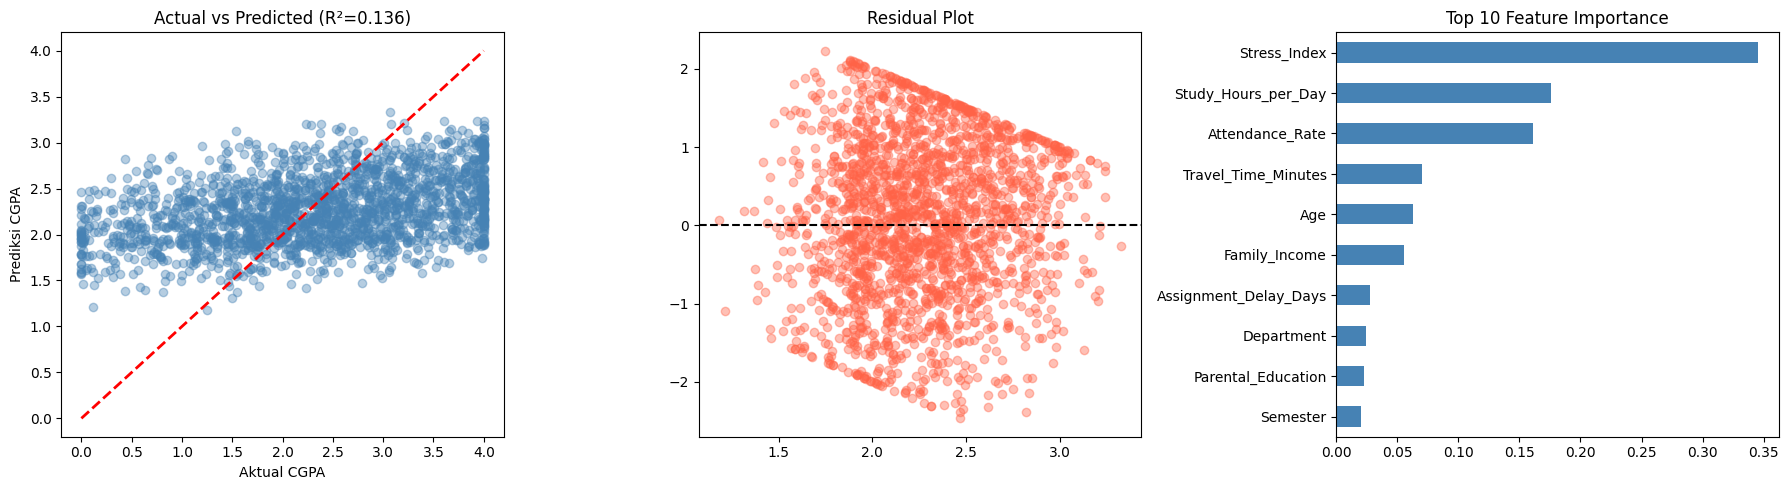

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.4, color='steelblue')
min_v, max_v = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
axes[0].plot([min_v, max_v], [min_v, max_v], 'r--', lw=2)
axes[0].set_xlabel('Aktual CGPA')
axes[0].set_ylabel('Prediksi CGPA')
axes[0].set_title(f'Actual vs Predicted (R²={r2:.3f})')

# Residual
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.4, color='tomato')
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title('Residual Plot')

# Feature Importance
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
feat_imp.plot(kind='barh', ax=axes[2], color='steelblue')
axes[2].set_title('Top 10 Feature Importance')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

---
## 6.  Cara Mengetahui Evaluasi Bagus atau Tidak

### R² untuk CGPA:
| R² | Interpretasi |
|----|-------------|
| > 0.85 | Model sangat baik |
| 0.70–0.85 | Baik |
| 0.50–0.70 | Cukup |
| < 0.50 | Perlu perbaikan |

### RMSE untuk CGPA (skala 0–4):
| RMSE | Interpretasi |
|------|-------------|
| < 0.1 | Sangat akurat |
| 0.1–0.25 | Baik |
| 0.25–0.5 | Cukup |
| > 0.5 | Kurang akurat |

### Cek OOB Score:
OOB (Out-of-Bag) score mengestimasi performa tanpa validation set terpisah. Mirip cross-validation tapi lebih cepat.

In [8]:
r2_train = r2_score(y_train, model.predict(X_train))
print(f'Train R²  : {r2_train:.4f}')
print(f'Test R²   : {r2:.4f}')
print(f'OOB R²    : {model.oob_score_:.4f}')

if r2_train - r2 > 0.1:
    print('  Overfitting! Turunkan max_depth, naikkan min_samples_leaf')
elif r2 < 0.5:
    print('  R² rendah. Pertimbangkan naikkan n_estimators atau XGBoost')
else:
    print('  Model terlihat baik!')

Train R²  : 0.4065
Test R²   : 0.1362
OOB R²    : 0.1960
  Overfitting! Turunkan max_depth, naikkan min_samples_leaf


---
## 7.  Cara Mengoptimasi Model

In [9]:
# Hyperparameter Tuning
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5]
}

rand_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_dist,
    n_iter=15,
    cv=5,
    scoring='r2',
    random_state=42
)

rand_search.fit(X_train, y_train)
best_model = rand_search.best_estimator_
y_best = best_model.predict(X_test)

print(f'Best params: {rand_search.best_params_}')
print(f'Best CV R²: {rand_search.best_score_:.4f}')
print(f'Test R² setelah tuning: {r2_score(y_test, y_best):.4f}')
print(f'Test RMSE setelah tuning: {np.sqrt(mean_squared_error(y_test, y_best)):.4f}')

Best params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': 5}
Best CV R²: 0.2023
Test R² setelah tuning: 0.1365
Test RMSE setelah tuning: 1.0054


---
## 8.  Cara Menyimpan Model

In [10]:
os.makedirs('saved_models', exist_ok=True)
joblib.dump(best_model, 'saved_models/rf_regressor_cgpa.pkl')
joblib.dump(list(X.columns), 'saved_models/feature_columns_rf_reg.pkl')
print(' Random Forest Regressor tersimpan!')
print(f'File size: {os.path.getsize("saved_models/rf_regressor_cgpa.pkl") / 1024:.1f} KB')

 Random Forest Regressor tersimpan!
File size: 1368.1 KB


---
## 9.  Cara Menggunakan Model Hasil Training

Random Forest tidak butuh scaler! Langsung prediksi dari data yang sudah di-encode.

In [11]:
loaded_model = joblib.load('saved_models/rf_regressor_cgpa.pkl')
loaded_cols = joblib.load('saved_models/feature_columns_rf_reg.pkl')

# Prediksi data baru
new_student = pd.DataFrame([{
    'Age': 21, 'Gender': 0, 'Family_Income': 40000,
    'Internet_Access': 1, 'Study_Hours_per_Day': 6.0,
    'Attendance_Rate': 92, 'Assignment_Delay_Days': 0,
    'Travel_Time_Minutes': 15, 'Part_Time_Job': 0,
    'Scholarship': 1, 'Stress_Index': 3,
    'Semester': 4, 'Department': 0, 'Parental_Education': 3
}])[loaded_cols]

predicted_cgpa = loaded_model.predict(new_student)[0]
print(f'Prediksi CGPA: {predicted_cgpa:.2f}')

# Prediksi batch
batch_preds = loaded_model.predict(X_test)
results = pd.DataFrame({'Aktual': y_test.values, 'Prediksi': batch_preds.round(2)})
results['Error'] = (results['Aktual'] - results['Prediksi']).abs().round(3)
print('\nContoh Batch Prediksi:')
print(results.head(10).to_string(index=False))

Prediksi CGPA: 3.22

Contoh Batch Prediksi:
 Aktual  Prediksi  Error
   3.95      1.95   2.00
   3.02      1.94   1.08
   1.46      1.94   0.48
   0.99      1.94   0.95
   2.84      1.94   0.90
   0.42      1.94   1.52
   2.56      1.97   0.59
   2.25      1.96   0.29
   3.94      2.05   1.89
   1.74      1.94   0.20
